In [0]:

from pyspark.sql.functions import col, when

# 1. Load the dataset
file_path = "/Volumes/workspace/default/task4_data/IMDB Dataset.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

# 2. Convert 'positive'/'negative' text labels into 1 and 0
# The model needs numbers, not words, for the 'label'
df_labeled = df.withColumn("label", 
    when(col("sentiment") == "positive", 1.0).otherwise(0.0))

# 3. Clean the data (keep only review and label)
df_nlp = df_labeled.select("review", "label").dropna()

display(df_nlp.limit(5))

review,label
"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side.",1.0
"""A wonderful little production. The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. The actors are extremely well chosen- Michael Sheen not only """"has got all the polari"""" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries",0.0
"""I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her """"sexy"""" image and jumped right into a average",0.0
"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.",0.0
"""Petter Mattei's """"Love in the Time of Money"""" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money",0.0


In [0]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml import Pipeline

# 1. Tokenizer: Splits sentences into individual words
tokenizer = Tokenizer(inputCol="review", outputCol="words")

# 2. StopWordsRemover: Deletes common words (the, is, at) that don't help sentiment
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")

# 3. HashingTF: Counts word frequencies
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=5000)

# 4. IDF (Inverse Document Frequency): Gives more weight to "important" words
idf = IDF(inputCol="rawFeatures", outputCol="features")

# Combine all steps into a single pipeline
pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf])
pipeline_model = pipeline.fit(df_nlp)
processed_data = pipeline_model.transform(df_nlp)

In [0]:
from pyspark.ml.classification import LogisticRegression

# 1. Split data (80% to train the model, 20% to test it)
train_data, test_data = processed_data.randomSplit([0.8, 0.2], seed=42)

# 2. Initialize and Train the model
lr = LogisticRegression(featuresCol="features", labelCol="label")
sentiment_model = lr.fit(train_data)

print("Task 4 Model Training Complete!")

Task 4 Model Training Complete!


In [0]:
# 1. This forces Spark to look at the data and will update the UI
display(train_data.limit(5))

# 2. This prints the structure in the console so you can see it
train_data.printSchema()

review,label,words,filtered_words,rawFeatures,features
""""""" Så som i himmelen """" .. as above so below.. that very special point where Divine and Human meet. I ADORE this film ! A gem. YES amazing grace !I was so deeply moved by its very HUMAN quality. I laughed and cried through a whole register",0.0,"List("""""", så, som, i, himmelen, """", .., as, above, so, below.., that, very, special, point, where, divine, and, human, meet., i, adore, this, film, !, a, gem., yes, amazing, grace, !i, was, so, deeply, moved, by, its, very, human, quality., i, laughed, and, cried, through, a, whole, register)","List("""""", så, som, himmelen, """", .., below.., special, point, divine, human, meet., adore, film, !, gem., yes, amazing, grace, !i, deeply, moved, human, quality., laughed, cried, whole, register)","{""type"":""0"",""size"":""5000"",""indices"":[""3"",""44"",""245"",""627"",""916"",""1055"",""1116"",""1437"",""1452"",""1549"",""1651"",""2346"",""2347"",""2589"",""2638"",""2908"",""3156"",""3303"",""3610"",""3701"",""3745"",""3818"",""3972"",""4083"",""4223"",""4416"",""4583"",""4948""],""values"":[""1.0"",""2.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""2.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}","{""type"":""0"",""size"":""5000"",""indices"":[""3"",""44"",""245"",""627"",""916"",""1055"",""1116"",""1437"",""1452"",""1549"",""1651"",""2346"",""2347"",""2589"",""2638"",""2908"",""3156"",""3303"",""3610"",""3701"",""3745"",""3818"",""3972"",""4083"",""4223"",""4416"",""4583"",""4948""],""values"":[""0.9665519481109046"",""6.296874722039284"",""0.7608894308563285"",""2.603169791076843"",""4.637713377493654"",""2.644813751267198"",""4.6607028957183525"",""5.213996217914288"",""4.412918298140971"",""4.317008238294662"",""5.143044481942004"",""5.002687124247082"",""5.394848266728883"",""4.114159189350283"",""4.658590962515209"",""5.08645700731254"",""4.843447374912352"",""5.809630556723783"",""4.801205069714051"",""5.192177170519649"",""4.976253867178926"",""5.314466748277923"",""5.343334732278775"",""4.613222357485358"",""4.260183046717044"",""2.9484870808868795"",""2.3706698237081776"",""5.146475017038793""]}"
"""""""A Thief in the Night"""" is a film that was generally ignored by movie fans at large due to its low-budget (which was obvious) and its subject matter--the Rapture of true Christian church and the fate of those left behind. Nevertheless",0.0,"List(""""""a, thief, in, the, night"""", is, a, film, that, was, generally, ignored, by, movie, fans, at, large, due, to, its, low-budget, (which, was, obvious), and, its, subject, matter--the, rapture, of, true, christian, church, and, the, fate, of, those, left, behind., nevertheless)","List(""""""a, thief, night"""", film, generally, ignored, movie, fans, large, due, low-budget, (which, obvious), subject, matter--the, rapture, true, christian, church, fate, left, behind., nevertheless)","{""type"":""0"",""size"":""5000"",""indices"":[""3"",""241"",""693"",""877"",""1273"",""1439"",""1662"",""1824"",""2022"",""2150"",""2188"",""2373"",""2566"",""2612"",""3271"",""3304"",""3416"",""3542"",""3655"",""3885"",""4156"",""4676"",""4720""],""values"":[""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}","{""type"":""0"",""size"":""5000"",""indices"":[""3"",""241"",""693"",""877"",""1273"",""1439"",""1662"",""1824"",""2022"",""2150"",""2188"",""2373"",""2566"",""2612"",""3271"",""3304"",""3416"",""3542"",""3655"",""3885"",""4156"",""4676"",""4720""],""values"":[""0.9665519481109046"",""4.8717632950296395"",""3.7541849206125684"",""3.711554144478745"",""3.089184218146546"",""0.8024018575663749"",""3.0474667090406724"",""3.7942599695717654"",""3.32536806917872"",""4.961865129726826"",""3.058053299551373"",""3.0606108457024903"",""4.

root
 |-- review: string (nullable = true)
 |-- label: double (nullable = false)
 |-- words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- filtered_words: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- rawFeatures: vectorudt (nullable = true)
 |-- features: vectorudt (nullable = true)



In [0]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 1. Make predictions on the test set
predictions = sentiment_model.transform(test_data)

# 2. Calculate Accuracy (Area Under ROC)
evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
accuracy = evaluator.evaluate(predictions)

print(f"Sentiment Prediction Accuracy: {accuracy:.4f}")

# 3. Compare Results
display(predictions.select("review","label","prediction").limit(100))

Sentiment Prediction Accuracy: 0.8481


review,label,prediction
"""""""A bored television director is introduced to the black arts and astral projection by his girlfriend. Learning the ability to separate his spirit from his body",0.0,0.0
"""""""A wrong-doer is often a man that has left something undone",0.0,0.0
"""""""Ah Ritchie's made another gangster film with Statham"""" thought the average fan",0.0,0.0
"""""""Ardh Satya"""" is one of the finest film ever made in Indian Cinema. Directed by the great director Govind Nihalani",0.0,0.0
"""""""Bell Book and Candle"""" was shown recently on cable. Not having seen it for a while",0.0,0.0
"""""""Cinderella"""" is one of the most beloved of all Disney classics. And it really deserves its status. Based on the classic fairy-tale as told by Charles Perrault",0.0,0.0
"""""""Death Lends A Hand"""" is one of the pivotal early episodes of """"Columbo"""" that helped define the show for the next thirty years. It marks the first of Robert Culp's four appearances (three as a murderer)",0.0,0.0
"""""""Dragonlord"""" sees Chan returning to his role of """"Dragon"""" from """"The Young Master"""". Not much has carried over from the first film though. """"Tiger""""",0.0,0.0
"""""""GI Samurai"""" sees Sonny Chiba and some other guys get transported back to civil war stricken feudal Japan for no particular reason",0.0,0.0
"""""""Girlfight"""" is much more of a coming-of-age-story than it is a fight flick. And what a relief to have one in an urban school",0.0,0.0


Databricks visualization. Run in Databricks to view.

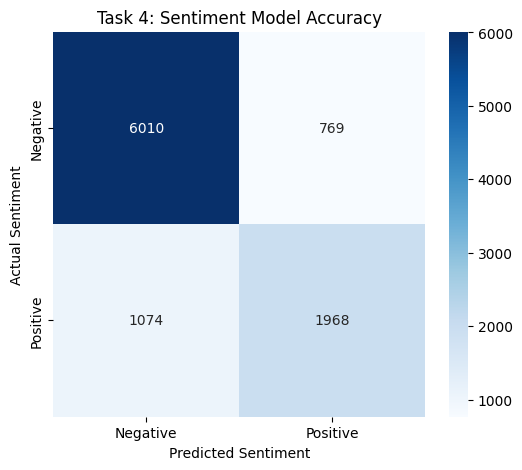

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# Convert Spark predictions to a small Pandas DataFrame for plotting
y_true = predictions.select("label").toPandas()
y_pred = predictions.select("prediction").toPandas()

# Create the Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.title('Task 4: Sentiment Model Accuracy')
plt.show()